Случайная величина имеет экспоненциальный закон распределения

   $$
   p(x) =
   \begin{cases}
   e^{-x}, & x \ge 0, \\
   0, & x < 0.
   \end{cases}
   $$

Сгенерируйте выборку объема \(n = 25\).

In [168]:
import numpy as np
from scipy import stats, special
import matplotlib.pyplot as plt

In [169]:
np.random.seed(46)

n = 25
data = np.random.exponential(scale=1, size=n)
data

array([1.53170102, 1.00740243, 0.28640701, 1.41913109, 0.37553298,
       2.76839525, 0.0438113 , 0.58136827, 2.43866017, 0.60697668,
       0.70914312, 0.08873062, 0.55573546, 1.3693073 , 2.01801834,
       0.39106799, 0.1098979 , 1.62003409, 0.50224909, 0.9882382 ,
       0.0366521 , 0.35654331, 0.04882605, 0.46555128, 0.30437421])

a) Определить по выборке моду, медиану, размах, оценку коэффициента асимметрии.

In [170]:
def mode(data):
    vals, counts = np.unique(data, return_counts=True)
    if vals.size == data.size:
        return np.array([])
    return vals[counts == max(counts)]

data_mode = mode(data)
data_median = np.median(data)
data_range = max(data) - min(data)


data_skewness = stats.moment(data, order=3)/(np.std(data) ** 3)

print(f"Мода: {data_mode}")
print(f"Медиана: {data_median}")
print(f"Размах: {data_range}")
print(f"Коэффициент ассиметрии: {data_skewness}")

Мода: []
Медиана: 0.5557354605176453
Размах: 2.7317431467654445
Коэффициент ассиметрии: 1.0902478455516986


b) Построить эмпирическую функцию распределения, гистограмму и boxplot.

$$F(x) = \int_{-\infty}^x p(t) dt = \int_{0}^x e^{-t} dt, x > 0$$
$$F(x) = -e^{-x} + e^{0} = 1 - e^{-x}$$

In [171]:
def get_hist_bin(n, sample):
    hist_min, hist_max = min(sample), max(sample)
    sample_range = hist_max - hist_min
    
    k = np.round(1 + np.log2(n))
    delta_i = sample_range / k

    bin_edges = np.arange(hist_min, hist_max + delta_i, delta_i)

    if bin_edges[-1] < hist_max:
        bin_edges = np.append(bin_edges, bin_edges[-1] + delta_i)

    frequencies = np.zeros(len(bin_edges) - 1)
    bin_centers = np.zeros(len(bin_edges) - 1)

    for i in range(len(bin_edges) - 1):
        left = bin_edges[i]
        right = bin_edges[i + 1]
        mask = (sample >= left) & (sample < right)
        if i == len(bin_edges) - 2:
            mask = (sample >= left) & (sample <= right)
        
        frequencies[i] = np.sum(mask)
        bin_centers[i] = (left + right) / 2

    relative_frequencies = frequencies / n

    return delta_i, bin_centers, relative_frequencies

Эмпирическая функция распределение

In [172]:
sorted_data = np.sort(data)
ecdf_y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# F(x)
x_ecdf_theor = np.linspace(0, np.max(data), 100)
y_ecdf_theor = 1 - np.exp(-x_ecdf_theor)

Гистограмма

In [173]:
delta_i, bin_centers, relative_frequencies = get_hist_bin(n, data)

# Теоретическая плотность
x_hist_theor = np.linspace(0, np.max(bin_centers) + delta_i, 100)
y_hist_theor = np.exp(-x_hist_theor)

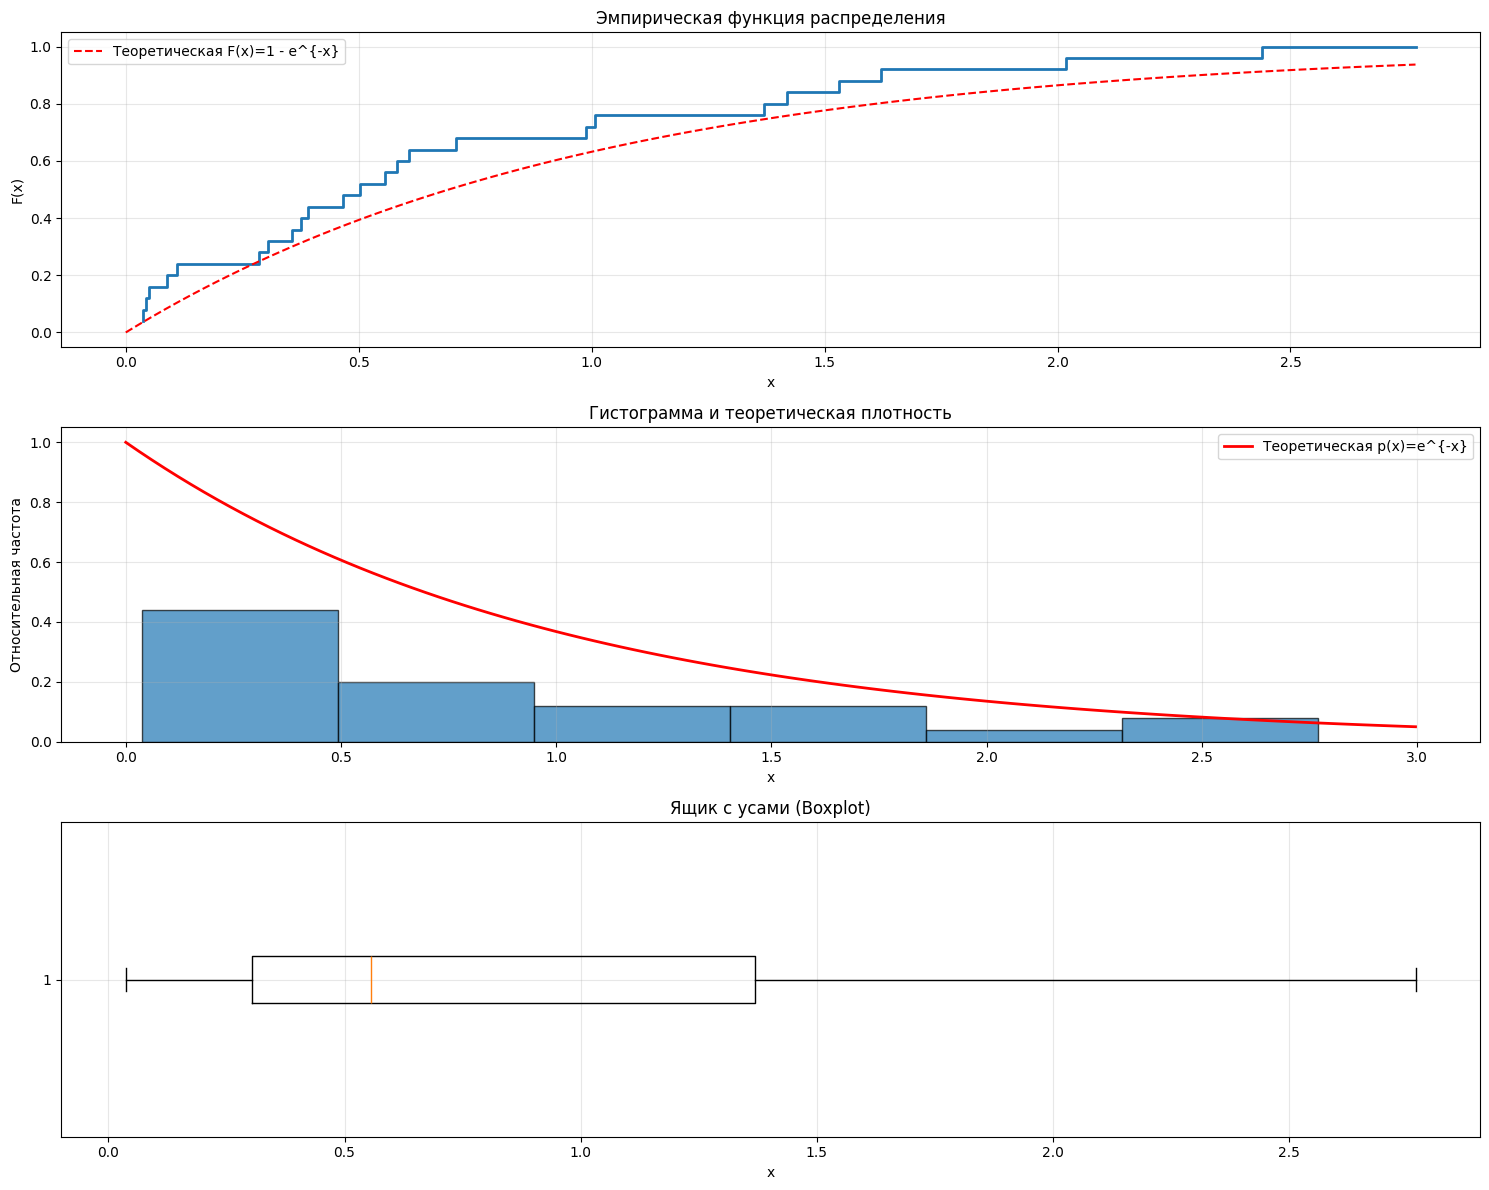

In [174]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Эмпирическая
ax1 = axes[0]

ax1.step(sorted_data, ecdf_y, linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('F(x)')
ax1.set_title('Эмпирическая функция распределения')
ax1.grid(True, alpha=0.3)

ax1.plot(x_ecdf_theor, y_ecdf_theor, 'r--', label='Теоретическая F(x)=1 - e^{-x}')
ax1.legend()

# Гистограмма
ax2 = axes[1]
ax2.bar(bin_centers, relative_frequencies, width=delta_i, 
               edgecolor='black', alpha=0.7)

ax2.plot(x_hist_theor, y_hist_theor, 'r-', linewidth=2, label='Теоретическая p(x)=e^{-x}')
ax2.set_xlabel('x')
ax2.set_ylabel('Относительная частота')
ax2.set_title('Гистограмма и теоретическая плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Boxplot
ax3 = axes[2]
ax3.boxplot(data, vert=False)
ax3.set_xlabel('x')
ax3.set_title('Ящик с усами (Boxplot)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  c) Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности.

Бутстрап

In [175]:
n_bootstrap = 10000

bootstrap_means = np.zeros(n_bootstrap)
for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(data, size=n, replace=True)
    bootstrap_means[i] = np.mean(bootstrap_sample)

bootstrap_delta_i, bootstrap_bin_centers, \
    bootstrap_relative_frequencies = get_hist_bin(n_bootstrap, bootstrap_means)


ЦПТ

$$\frac{\Sigma\xi_{i} - n * m\xi}{\sqrt{n*D\xi}}\leadsto N(0, 1)$$
$$\frac{\frac{\Sigma x_{i}}{n} - m\xi}{\sqrt{n*D\xi}} \sqrt{n} \leadsto N(0, 1)$$
$$m\xi = \int_{0}^{\infty} xe^{-x} dx = [-xe^{-x}]_{0}^{\infty} + \int_{0}^{\infty} e^{-x} dx$$
$$m\xi = \int_{0}^{\infty} e^{-x} dx = [-e^{-x}]_{0}^{\infty} = 1$$

$$m\xi^2 = \int_{0}^{\infty} x^2e^{-x} dx = [-x^2e^{-x}]_{0}^{\infty} + \int_{0}^{\infty} 2xe^{-x} dx$$
$$m\xi^2 = \int_{0}^{\infty} 2xe^{-x} dx = [-2xe^{-x}]_{0}^{\infty} + \int_{0}^{\infty} 2e^{-x} dx$$
$$m\xi^2 = 2[-e^{-x}]_{0}^{\infty} = 2$$

$$D\xi = 2 - 1 = 1$$

$$\frac{\bar{x} - 1}{\sqrt{1}}\sqrt{25} \leadsto N(0, 1)$$
$$\bar{x} \leadsto N(1, 0.04)$$

In [176]:
mu_hat = 1
sigma_hat = 1
se = sigma_hat / np.sqrt(n)

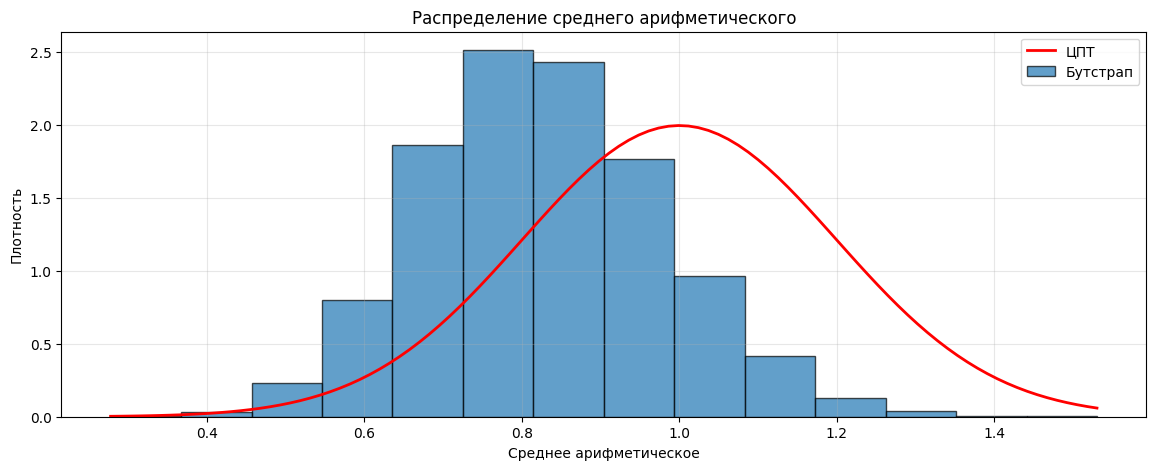

In [177]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Бутстрап
axes.bar(bootstrap_bin_centers, bootstrap_relative_frequencies / bootstrap_delta_i, width=bootstrap_delta_i, 
               edgecolor='black', alpha=0.7, label="Бутстрап")

# Нормальное распределение по ЦПТ с оцененными параметрами
x_norm = np.linspace(min(bootstrap_means), max(bootstrap_means), 100)
y_norm = stats.norm.pdf(x_norm, mu_hat, se)
axes.plot(x_norm, y_norm, 'r-', linewidth=2, label='ЦПТ')

axes.set_xlabel('Среднее арифметическое')
axes.set_ylabel('Плотность')
axes.set_title('Распределение среднего арифметического')
axes.legend()
axes.grid(True, alpha=0.3)

d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1.

In [178]:
bootstrap_skewness = np.zeros(n_bootstrap)

for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(data, size=n, replace=True)
    bootstrap_skewness[i] = stats.skew(bootstrap_sample)

prob = np.mean(bootstrap_skewness < 1)
print(f"P(skewness < 1) = {prob:.4f}")

bootstrap_delta_i, bootstrap_bin_centers, \
    bootstrap_relative_frequencies = get_hist_bin(n_bootstrap, bootstrap_skewness)

P(skewness < 1) = 0.4855


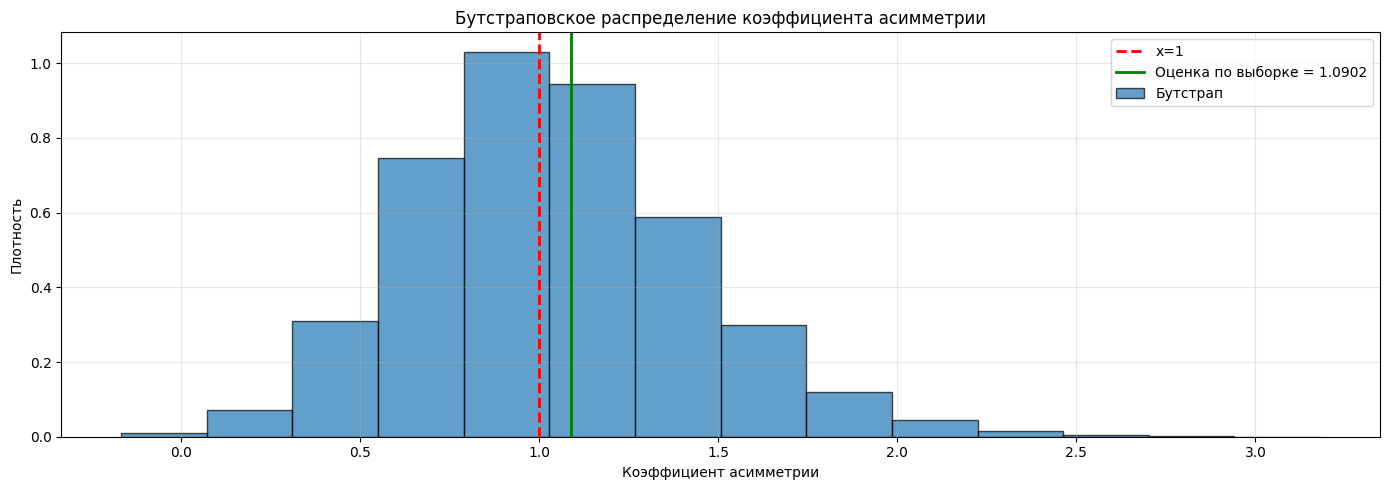

In [179]:
fig, axes = plt.subplots(1, figsize=(14, 5))

# Гистограмма распределения коэффициента асимметрии
axes.bar(bootstrap_bin_centers, bootstrap_relative_frequencies / bootstrap_delta_i, width=bootstrap_delta_i, 
               edgecolor='black', alpha=0.7, label="Бутстрап")
axes.axvline(x=1, color='r', linestyle='--', linewidth=2, label='x=1')
axes.axvline(x=data_skewness, color='g', linestyle='-', linewidth=2, label=f'Оценка по выборке = {data_skewness:.4f}')
axes.set_xlabel('Коэффициент асимметрии')
axes.set_ylabel('Плотность')
axes.set_title('Бутстраповское распределение коэффициента асимметрии')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности.

Бутстрап

In [180]:
bootstrap_medians = np.zeros(n_bootstrap)

for i in range(n_bootstrap):
    bootstrap_sample = np.random.choice(data, size=n, replace=True)
    bootstrap_medians[i] = np.median(bootstrap_sample)

bootstrap_delta_i, bootstrap_bin_centers, \
    bootstrap_relative_frequencies = get_hist_bin(n_bootstrap, bootstrap_medians)

Плотность распределения медианы

$$Ф_{med} = \Sigma_{i = 13}^{25} C_{25}^i (F(t))^i (1 - F(t))^{25 - i}$$
$$p_{med} = (Ф_{med})' = \Sigma_{i = 13}^{25} C_{25}^i (i (F(t))^{i - 1} (1 - F(t))^{25 - i} F(t)' + (i - 25) (F(t))^i (1 - F(t))^{24 - i} F(t)')$$
$$p_{med} = p(t) \Sigma_{i = 13}^{25} C_{25}^i (F(t))^{i - 1} (1 - F(t))^{24 - i} (i (1 - F(t)) + (i - 25) (F(t)))$$
$$p_{med} = e^{-x} \Sigma_{i = 13}^{25} C_{25}^i (1 - e^{-x})^{i - 1} (e^{-x})^{24 - i} (i e^{-x} + (i - 25) (1 - e^{-x}))$$

In [181]:
def F_exp(x):
    return 1 - np.exp(-x) if x > 0 else 0

def f_exp(x):
    return np.exp(-x) if x > 0 else 0

def median_density(t, n=25):
    if t <= 0:
        return 0
    
    F_t = F_exp(t)
    f_t = f_exp(t)
    
    density = 0
    for i in range(13, n + 1):
        coef = special.comb(n, i)
        density += coef * F_t ** (i - 1) * (1 - F_t) ** (24 - i) * (i * (1 - F_t) + (i - 25) * F_t)
    
    return density * f_t

$$1 - e^{-x} = 0.5$$
$$e^{-x} = 0.5$$
$$x = \ln{2}$$

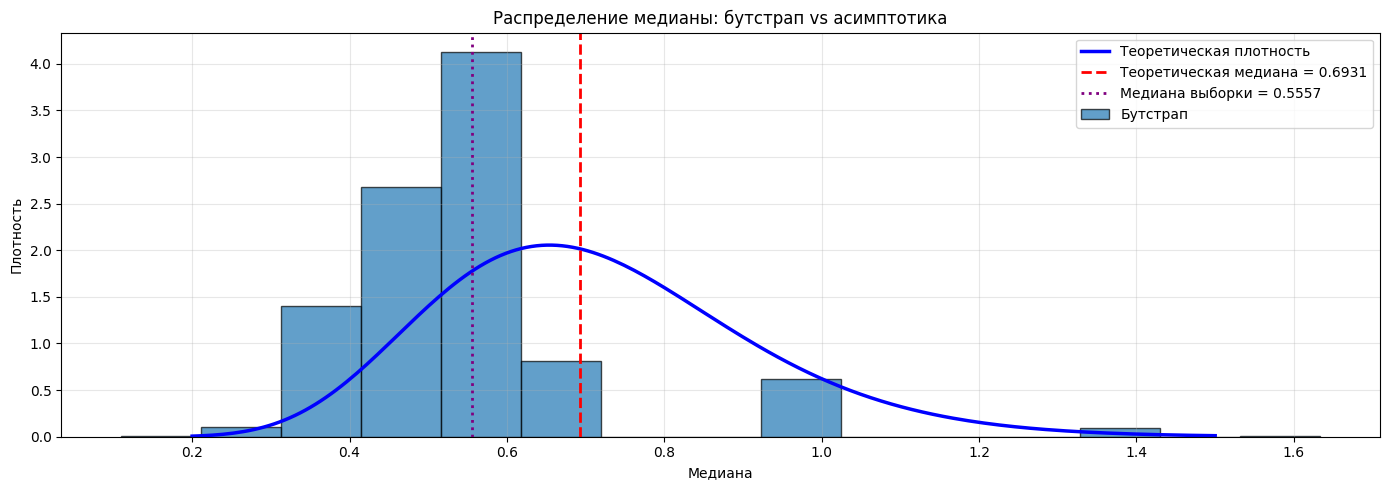

In [182]:
fig, axes = plt.subplots(1, figsize=(14, 5))

# Гистограмма бутстраповских медиан
axes.bar(bootstrap_bin_centers, bootstrap_relative_frequencies / bootstrap_delta_i, width=bootstrap_delta_i, 
               edgecolor='black', alpha=0.7, label="Бутстрап")

# Теория
x_theor = np.linspace(0.2, 1.5, 200)
y_theor = [median_density(x) for x in x_theor]
axes.plot(x_theor, y_theor, 'b-', linewidth=2.5, label='Теоретическая плотность')

theor_median = np.log(2)
axes.axvline(theor_median, color='red', linestyle='--', linewidth=2, 
            label=f'Теоретическая медиана = {theor_median:.4f}')
axes.axvline(data_median, color='purple', linestyle=':', linewidth=2, 
            label=f'Медиана выборки = {data_median:.4f}')

axes.set_xlabel('Медиана')
axes.set_ylabel('Плотность')
axes.set_title('Распределение медианы: бутстрап vs асимптотика')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()